# Electrical System Components

**Learning Goals**
- Understand the three passive electrical components: resistor, capacitor, inductor
- Know the voltage-current relationship for each component
- Apply Kirchhoff's Voltage Law (KVL) and Kirchhoff's Current Law (KCL)
- Reduce series and parallel combinations of components to a single equivalent value

In [4]:
%pip install -q ipywidgets schemdraw

Note: you may need to restart the kernel to use updated packages.


In [5]:
import schemdraw
import schemdraw.elements as elm
import ipywidgets as widgets
from IPython.display import display, clear_output

print("Libraries loaded.")

Libraries loaded.


In [6]:
from IPython.display import HTML
pdf_url = "week3.pdf"
HTML(f'<embed src="{pdf_url}" type="application/pdf" width="100%" height="500px" />')

---

## Passive Electrical Components

Electrical circuits in control systems are built from three fundamental passive components: **resistor**, **capacitor**, and **inductor**. Each has a distinct voltage-current relationship that defines how it behaves in a circuit.

### Resistor

A resistor opposes the flow of electric current, converting electrical energy into heat.

**Ohm's Law:**
$$V = I \cdot R$$

where $V$ is the voltage across the resistor (volts), $I$ is the current through it (amps), and $R$ is the resistance (ohms, $\Omega$).

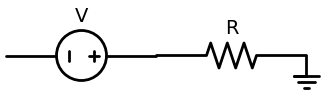

In [24]:
with schemdraw.Drawing() as d:
    elm.SourceV().label('V').right()
    elm.Resistor().label('R').right()
    elm.Ground()
#display(d)

---

### Capacitor

A capacitor stores energy in an electric field between two conductive plates separated by an insulator.

**Voltage-Current Relationship:**
$$i(t) = C \frac{d v(t)}{d t} \qquad \Longleftrightarrow \qquad v(t) = \frac{1}{C} \int_{0}^{t} i(\tau) \, d\tau + v(0)$$

where $C$ is the capacitance (farads).

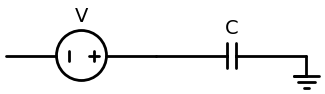

In [25]:
with schemdraw.Drawing() as d:
    elm.SourceV().label('V').right()
    elm.Capacitor().label('C').right()
    elm.Ground()
#display(d)

---

### Inductor

An inductor stores energy in a magnetic field around a coil of wire.

**Voltage-Current Relationship:**
$$v(t) = L \frac{d i(t)}{d t} \qquad \Longleftrightarrow \qquad i(t) = \frac{1}{L} \int_{0}^{t} v(\tau) \, d\tau + i(0)$$

where $L$ is the inductance (henries).

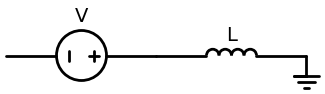

In [26]:
with schemdraw.Drawing() as d:
    elm.SourceV().label('V').right()
    elm.Inductor().label('L').right()
    elm.Ground()
#display(d)

---

## Kirchhoff's Laws

Two fundamental laws govern how voltages and currents behave in any electrical circuit.

### Kirchhoff's Voltage Law (KVL)

**The sum of voltages around any closed loop is zero.**

$$\sum_{k=1}^{n} V_k = 0$$

This is a consequence of energy conservation: as you travel around a closed loop, you return to the same potential.

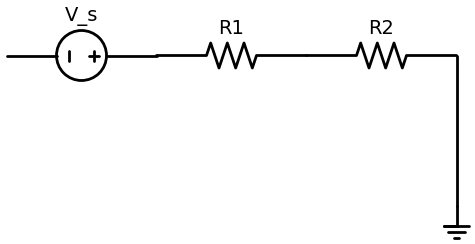

In [27]:
with schemdraw.Drawing() as d:
    elm.SourceV().label('V_s').right()
    elm.Resistor().label('R1').right()
    elm.Resistor().label('R2').right()
    elm.Line().down()
    elm.Ground()
#display(d)

For the circuit above, KVL gives:

$$V_s - V_{R1} - V_{R2} = 0$$

or equivalently $V_s = V_{R1} + V_{R2}$.

### Kirchhoff's Current Law (KCL)

**The sum of currents entering a node equals the sum of currents leaving it.**

$$\sum I_{\text{in}} = \sum I_{\text{out}}$$

This is a consequence of charge conservation: charge cannot accumulate at a node.

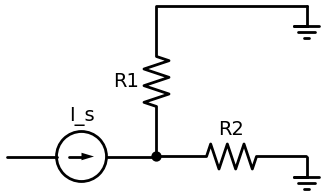

In [28]:
with schemdraw.Drawing() as d:
    elm.SourceI().label('I_s').right()
    elm.Dot()
    d.push()
    elm.Resistor().label('R1').up()
    elm.Line().right()
    elm.Ground()
    d.pop()
    elm.Resistor().label('R2').right()
    elm.Ground()
#display(d)

For the circuit above, KCL at the top node gives:

$$I_s = I_{R1} + I_{R2}$$

---

## Series and Parallel Reduction

When components are connected in **series** or **parallel**, they can be replaced by a single **equivalent** component. This is a key skill for simplifying circuits before analysis.

### Resistor Reduction

| Connection | Equivalent Resistance |
|------------|----------------------|
| Series | $R_{\text{eq}} = R_1 + R_2$ |
| Parallel | $R_{\text{eq}} = \dfrac{R_1 \cdot R_2}{R_1 + R_2}$ |

**Try it!** Use the sliders below to adjust two resistors and see the equivalent values.

In [29]:
R1_slider = widgets.FloatSlider(min=1, max=100, step=1, value=10,
                                description='R1 (\u03A9):',
                                style={'description_width': 'initial'})
R2_slider = widgets.FloatSlider(min=1, max=100, step=1, value=20,
                                description='R2 (\u03A9):',
                                style={'description_width': 'initial'})
r_out = widgets.Output()

def draw_resistor_circuits(R1, R2):
    display(widgets.HTML('<b>Series:</b>'))
    with schemdraw.Drawing() as d:
        elm.SourceV().label('V_s').right()
        elm.Resistor().label(f'R1={R1:.0f}\u03A9').right()
        elm.Resistor().label(f'R2={R2:.0f}\u03A9').right()
        elm.Line().down()
        elm.Ground()
    #display(d)
    display(widgets.HTML('<b>Parallel:</b>'))
    with schemdraw.Drawing() as d:
        elm.SourceV().label('V_s').right()
        elm.Dot()
        d.push()
        elm.Resistor().label(f'R1={R1:.0f}\u03A9').up()
        elm.Line().right()
        elm.Ground()
        d.pop()
        elm.Resistor().label(f'R2={R2:.0f}\u03A9').right()
        elm.Ground()
    #display(d)
    display(widgets.HTML('<b>Series equivalent:</b>'))
    with schemdraw.Drawing() as d:
        elm.SourceV().label('V_s').right()
        elm.Resistor().label(f'R_eq={R1 + R2:.1f}\u03A9')
        elm.Ground()
    #display(d)
    display(widgets.HTML('<b>Parallel equivalent:</b>'))
    with schemdraw.Drawing() as d:
        elm.SourceV().label('V_s').right()
        elm.Resistor().label(f'R_eq={(R1 * R2) / (R1 + R2):.1f}\u03A9')
        elm.Ground()
    #display(d)

def update_resistors(b=None):
    R1 = R1_slider.value
    R2 = R2_slider.value
    R_series = R1 + R2
    R_parallel = (R1 * R2) / (R1 + R2)
    with r_out:
        clear_output(wait=True)
        draw_resistor_circuits(R1, R2)
        print(f'Series:  R_eq = {R1:.1f} + {R2:.1f} = {R_series:.1f} \u03A9')
        print(f'Parallel: R_eq = ({R1:.1f} \u00d7 {R2:.1f}) / ({R1:.1f} + {R2:.1f}) = {R_parallel:.2f} \u03A9')

R1_slider.observe(update_resistors, 'value')
R2_slider.observe(update_resistors, 'value')
update_resistors()
display(widgets.VBox([R1_slider, R2_slider, r_out]))

### Capacitor Reduction

> **Note:** Capacitors combine opposite to resistors: series uses the product-over-sum formula and parallel is additive.

| Connection | Equivalent Capacitance |
|------------|------------------------|
| Series | $C_{\text{eq}} = \dfrac{C_1 \cdot C_2}{C_1 + C_2}$ |
| Parallel | $C_{\text{eq}} = C_1 + C_2$ |

In [30]:
C1_slider = widgets.FloatSlider(min=1, max=100, step=1, value=10,
                                description='C1 (\u03BCF):',
                                style={'description_width': 'initial'})
C2_slider = widgets.FloatSlider(min=1, max=100, step=1, value=20,
                                description='C2 (\u03BCF):',
                                style={'description_width': 'initial'})
c_out = widgets.Output()

def draw_capacitor_circuits(C1, C2):
    display(widgets.HTML('<b>Series:</b>'))
    with schemdraw.Drawing() as d:
        elm.SourceV().label('V_s').right()
        elm.Capacitor().label(f'C1={C1:.0f}\u03BCF').right()
        elm.Capacitor().label(f'C2={C2:.0f}\u03BCF').right()
        elm.Line().down()
        elm.Ground()
    #display(d)
    display(widgets.HTML('<b>Parallel:</b>'))
    with schemdraw.Drawing() as d:
        elm.SourceV().label('V_s').right()
        elm.Dot()
        d.push()
        elm.Capacitor().label(f'C1={C1:.0f}\u03BCF').up()
        elm.Line().right()
        elm.Ground()
        d.pop()
        elm.Capacitor().label(f'C2={C2:.0f}\u03BCF').right()
        elm.Ground()
    #display(d)
    display(widgets.HTML('<b>Series equivalent:</b>'))
    with schemdraw.Drawing() as d:
        elm.SourceV().label('V_s').right()
        elm.Capacitor().label(f'C_eq={(C1 * C2) / (C1 + C2):.1f}\u03BCF')
        elm.Ground()
    #display(d)
    display(widgets.HTML('<b>Parallel equivalent:</b>'))
    with schemdraw.Drawing() as d:
        elm.SourceV().label('V_s').right()
        elm.Capacitor().label(f'C_eq={C1 + C2:.1f}\u03BCF')
        elm.Ground()
    #display(d)

def update_capacitors(b=None):
    C1 = C1_slider.value
    C2 = C2_slider.value
    C_series = (C1 * C2) / (C1 + C2)
    C_parallel = C1 + C2
    with c_out:
        clear_output(wait=True)
        draw_capacitor_circuits(C1, C2)
        print(f'Series:  C_eq = ({C1:.1f} \u00d7 {C2:.1f}) / ({C1:.1f} + {C2:.1f}) = {C_series:.2f} \u03BCF')
        print(f'Parallel: C_eq = {C1:.1f} + {C2:.1f} = {C_parallel:.1f} \u03BCF')

C1_slider.observe(update_capacitors, 'value')
C2_slider.observe(update_capacitors, 'value')
update_capacitors()
display(widgets.VBox([C1_slider, C2_slider, c_out]))

### Inductor Reduction

Inductors combine like resistors (series adds, parallel uses product-over-sum).

| Connection | Equivalent Inductance |
|------------|----------------------|
| Series | $L_{\text{eq}} = L_1 + L_2$ |
| Parallel | $L_{\text{eq}} = \dfrac{L_1 \cdot L_2}{L_1 + L_2}$ |

In [31]:
L1_slider = widgets.FloatSlider(min=1, max=100, step=1, value=10,
                                description='L1 (mH):',
                                style={'description_width': 'initial'})
L2_slider = widgets.FloatSlider(min=1, max=100, step=1, value=20,
                                description='L2 (mH):',
                                style={'description_width': 'initial'})
l_out = widgets.Output()

def draw_inductor_circuits(L1, L2):
    display(widgets.HTML('<b>Series:</b>'))
    with schemdraw.Drawing() as d:
        elm.SourceV().label('V_s').right()
        elm.Inductor().label(f'L1={L1:.0f}mH').right()
        elm.Inductor().label(f'L2={L2:.0f}mH').right()
        elm.Line().down()
        elm.Ground()
    #display(d)
    display(widgets.HTML('<b>Parallel:</b>'))
    with schemdraw.Drawing() as d:
        elm.SourceV().label('V_s').right()
        elm.Dot()
        d.push()
        elm.Inductor().label(f'L1={L1:.0f}mH').up()
        elm.Line().right()
        elm.Ground()
        d.pop()
        elm.Inductor().label(f'L2={L2:.0f}mH').right()
        elm.Ground()
    #display(d)
    display(widgets.HTML('<b>Series equivalent:</b>'))
    with schemdraw.Drawing() as d:
        elm.SourceV().label('V_s').right()
        elm.Inductor().label(f'L_eq={L1 + L2:.1f}mH')
        elm.Ground()
    #display(d)
    display(widgets.HTML('<b>Parallel equivalent:</b>'))
    with schemdraw.Drawing() as d:
        elm.SourceV().label('V_s').right()
        elm.Inductor().label(f'L_eq={(L1 * L2) / (L1 + L2):.1f}mH')
        elm.Ground()
    #display(d)

def update_inductors(b=None):
    L1 = L1_slider.value
    L2 = L2_slider.value
    L_series = L1 + L2
    L_parallel = (L1 * L2) / (L1 + L2)
    with l_out:
        clear_output(wait=True)
        draw_inductor_circuits(L1, L2)
        print(f'Series:  L_eq = {L1:.1f} + {L2:.1f} = {L_series:.1f} mH')
        print(f'Parallel: L_eq = ({L1:.1f} \u00d7 {L2:.1f}) / ({L1:.1f} + {L2:.1f}) = {L_parallel:.2f} mH')

L1_slider.observe(update_inductors, 'value')
L2_slider.observe(update_inductors, 'value')
update_inductors()
display(widgets.VBox([L1_slider, L2_slider, l_out]))

---

## Summary

| Component | Symbol | Voltage-Current Relation | Series | Parallel |
|-----------|--------|--------------------------|--------|----------|
| **Resistor** | $R$ | $V = IR$ | $R_1 + R_2$ | $\dfrac{R_1 R_2}{R_1 + R_2}$ |
| **Capacitor** | $C$ | $i = C\frac{dv}{dt}$ | $\dfrac{C_1 C_2}{C_1 + C_2}$ | $C_1 + C_2$ |
| **Inductor** | $L$ | $v = L\frac{di}{dt}$ | $L_1 + L_2$ | $\dfrac{L_1 L_2}{L_1 + L_2}$ |

These building blocks form the foundation for all analog circuit modeling and will be used extensively when we derive transfer functions for electrical systems.